# Análisis de imágenes IR en proceso de soldadura

## Visualizar imagenes

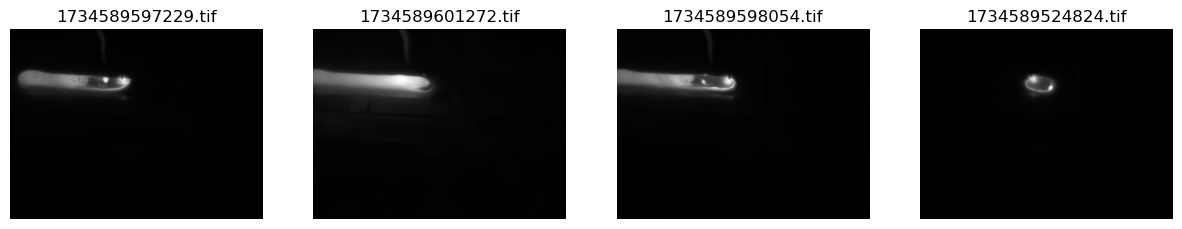

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image 

images_path = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Data'

images = os.listdir(images_path)
num_images = 4
selected_images = random.sample(images,num_images)
plt.figure(figsize=(15,5))
for i, file_name in enumerate (selected_images):
    img_path = os.path.join(images_path,file_name)
    img = Image.open(img_path)
    plt.subplot(1,num_images,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(file_name)
    plt.axis('off')
plt.show()


In [4]:
def plot_random_images (images_path, num_images):
    images = os.listdir(images_path)
    selected_images = random.sample(images,num_images)
    plt.figure(figsize=(15,5))
    for i, file_name in enumerate (selected_images):
        img_path = os.path.join(images_path,file_name)
        img = Image.open(img_path)
        plt.subplot(1,num_images,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(file_name)
        plt.axis('off')
    plt.show()

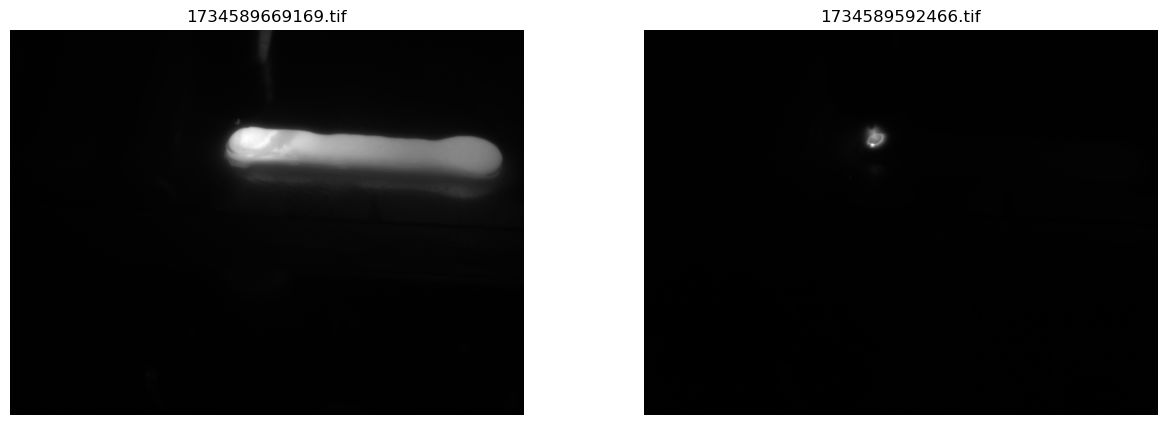

In [5]:
plot_random_images(images_path,2)

## dividir el dataset Train y test

Train: Son imagenes para probar los algoritmos de filtrado y procesamiento

Test : Evaluar los filtros seleccionados

In [6]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

images_path = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Data'
dataset_path = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset'
test_dir = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset/test'
train_dir = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset/train'
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


images = os.listdir(images_path)

train_images, test_images = train_test_split(images, train_size=0.8, random_state=42) 

for file in train_images:
    shutil.copy2(os.path.join(images_path,file),os.path.join(train_dir,file))
    
for file in test_images:
    shutil.copy2(os.path.join(images_path,file),os.path.join(test_dir,file))
    
print(f"Imagenes en train listas: {len(train_images)}")
print(f"Imagenes en test listas: {len(test_images)}")    



Imagenes en train listas: 277
Imagenes en test listas: 70


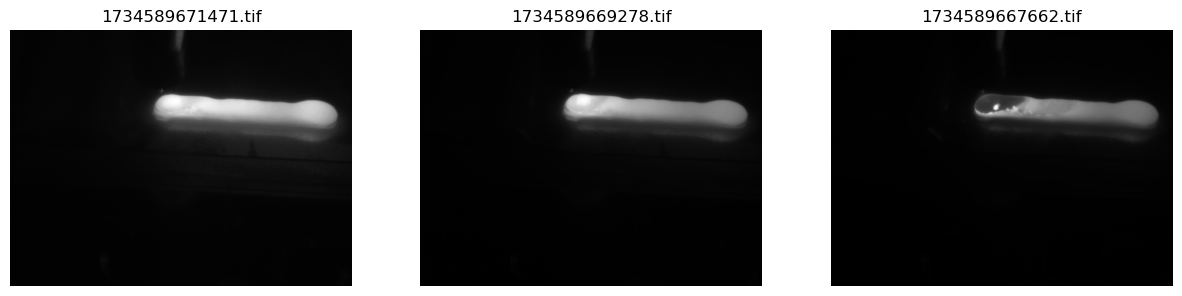

In [8]:
test_dir = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset/test'
plot_random_images(test_dir,3)

## Clustering 

Tecnica de segmentacion para procesamiento de datos o imagenes, este algortimos trabaja solo con vectores y no con matrices como lo son las imagenes

0          | 136.50     | 128      | 152     
1          | 80.00      | 80       | 80      
2          | 93.88      | 91       | 98      
3          | 86.69      | 84       | 90      
4          | 117.81     | 111      | 127     
5          | 81.30      | 81       | 83      
6          | 102.58     | 99       | 110     


<function matplotlib.pyplot.show(close=None, block=None)>

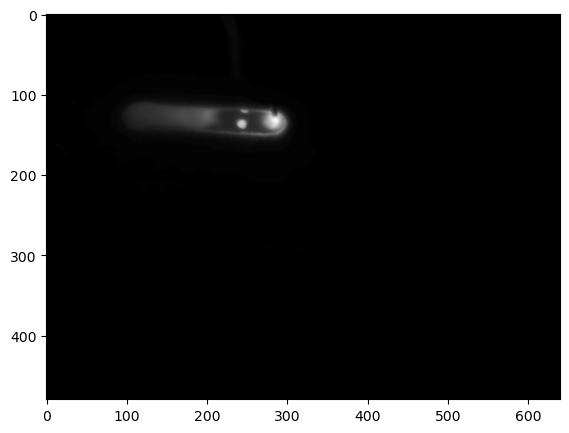

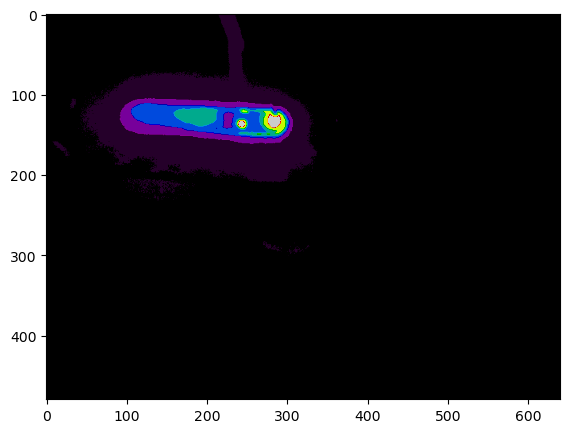

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset/train/1734589458148.tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
n_clusters = 7
# APLANAR A LA IMAGEN -> VECTOR 
# IMAGEN:
    # [1,2,3]
    # [4,5,6]
    # [7,8,9]
# VECTOR:  [1,2,3,4,5,6,7,8,9]

pixel_values = img.reshape((-1,1)) # aplano la imagen
pixel_values = np.float32(pixel_values) # convierto a float32

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = centers.flatten()
labels = labels.flatten()

# crea una imagen vacia para recostruir los cluster

segmented_data = np.zeros_like(pixel_values)

for i in range (n_clusters):
    cluster_pixels = pixel_values[labels == i] # si el cluster de etiqueta i, le corresponde a un pixel del vector
    if cluster_pixels.size > 0:
        c_min = np.min(cluster_pixels)
        c_max = np.max(cluster_pixels)
        c_center =  centers[i]
        print(f"{i:<10} | {c_center:<10.2f} | {c_min:<8.0f} | {c_max:<8.0f}")
        segmented_data[labels == i] = c_center

segmented_image = segmented_data.reshape(img.shape).astype(np.uint8)

plt.figure(figsize=(15,5))
plt.imshow(img,cmap='gray')
plt.show

plt.figure(figsize=(15,5))
plt.imshow(segmented_image,cmap='nipy_spectral')
plt.show    


## Generalizar el cluster

In [3]:
train_dir = '/home/paul/Documentos/Personal/UIDE/MATERIAS/Semana 2/PRACTICAS/Proyecto/Dataset/train'

images = os.listdir(train_dir)
n_clusters = 5
all_pixels = []

for file_name in images:
    img_path = os.path.join(train_dir,file_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    all_pixels.append(img.flatten())
    
pixel_values = np.concatenate(all_pixels).reshape(-1,1)
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = centers.flatten()
labels = labels.flatten()

for i in range (n_clusters):
    cluster_pixels = pixel_values[labels == i] # si el cluster de etiqueta i, le corresponde a un pixel del vector
    if cluster_pixels.size > 0:
        c_min = np.min(cluster_pixels)
        c_max = np.max(cluster_pixels)
        c_center =  centers[i]
        print(f"{i:<10} | {c_center:<10.2f} | {c_min:<8.0f} | {c_max:<8.0f}")


0          | 16.17      | 16       | 18      
1          | 24.00      | 24       | 24      
2          | 27.16      | 26       | 81      
3          | 91.86      | 82       | 240     
4          | 21.33      | 20       | 22      


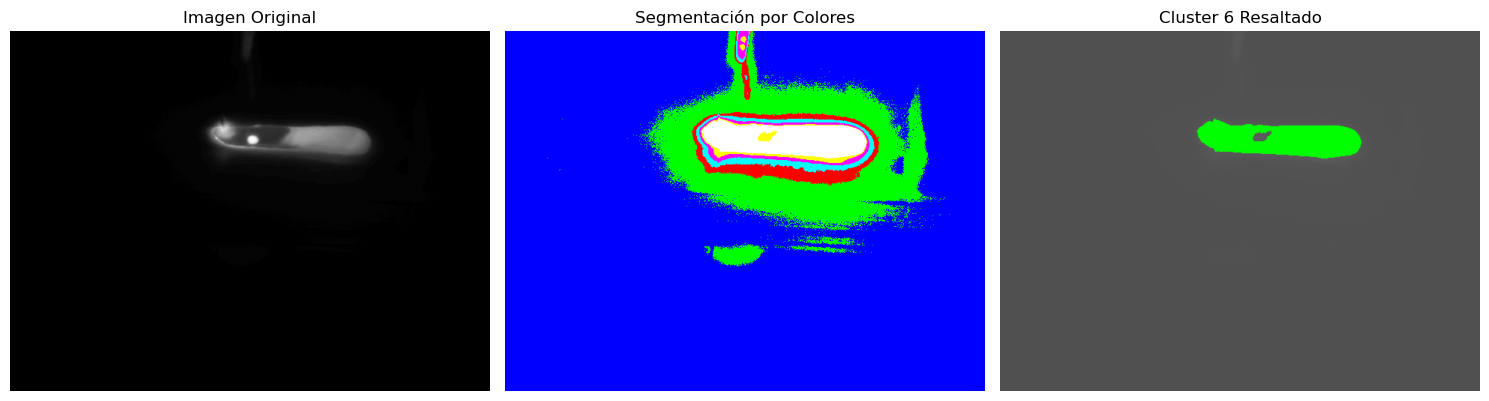

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_fixed_clusters(image_path, target_cluster=None):
    # 1. Cargar la imagen nueva
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("No se pudo cargar la imagen")

    # 2. Definir los centroides que obtuviste (ordenados de menor a mayor para consistencia)
    # Valores: 80.00, 81.00, 82.00, 83.59, 85.90, 89.11, 91.87
    centers = np.array([80.00, 81.00, 82.00, 83.59, 85.90, 89.11, 91.87], dtype=np.float32)
    
    # 3. Asignar cada píxel al centroide más cercano
    # Calculamos la diferencia absoluta entre cada píxel y todos los centroides
    pixel_values = img.astype(np.float32)
    # Expandimos dimensiones para restar de forma vectorial
    distances = np.abs(pixel_values[:, :, np.newaxis] - centers)
    # El índice del centroide con la distancia mínima es nuestro 'label'
    labels = np.argmin(distances, axis=2)

    # 4. Definir una paleta de colores para los 7 clusters (BGR)
    colors = [
        [255, 0, 0],    # Cluster 0: Azul
        [0, 255, 0],    # Cluster 1: Verde
        [0, 0, 255],    # Cluster 2: Rojo
        [255, 255, 0],  # Cluster 3: Cyan
        [255, 0, 255],  # Cluster 4: Magenta
        [0, 255, 255],  # Cluster 5: Amarillo
        [255, 255, 255] # Cluster 6: Blanco
    ]

    # 5. Crear la imagen coloreada
    h, w = img.shape
    colored_img = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i in range(len(centers)):
        colored_img[labels == i] = colors[i]

    # 6. Si se selecciona un cluster objetivo, crear una máscara de resalte
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    plt.title("Segmentación por Colores")
    plt.axis('off')

    if target_cluster is not None:
        # Resaltar solo el cluster elegido sobre la imagen gris
        highlight = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        highlight[labels == target_cluster] = [0, 255, 0] # Verde brillante
        
        plt.subplot(1, 3, 3)
        plt.imshow(highlight)
        plt.title(f"Cluster {target_cluster} Resaltado")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Ejecución ---
# Sustituye con la ruta de tu nueva imagen
nueva_imagen = '/home/paul/Documentos/FFT/Proyecto/Data/test/1734589527127.tif'
apply_fixed_clusters(nueva_imagen, target_cluster=6)